# Data Science & AI

**Group name:** The Turtur Squad

## all required installs:

pip install imbalanced-learn <br>
pip install geopandas <br>
pip install pandas <br>
pip install matplotlib <br>
pip install scikit-learn <br>
pip install numpy <br>
pip install seaborn

**Import libraries**


In [17]:
# import 

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

## Load datasets

In [5]:
# CSV import

habitats_df = pd.read_csv('data/habitats_cbs_2022.csv')
turtur_df = pd.read_csv(
    'data/Streptopelia turtur.csv/Streptopelia turtur.csv',
    dtype={'Streptopelia turtur': 'object'}
)

# Target cleaning & Presence (0 of 1)
turtur_df = turtur_df.rename(columns={'Streptopelia turtur': 'Streptopelia_turtur'})
target_numeric = pd.to_numeric(turtur_df['Streptopelia_turtur'], errors='coerce')
unknown_target_values = target_numeric.isna().sum()
turtur_df['Streptopelia_turtur'] = target_numeric.fillna(0)
turtur_df['presence'] = (turtur_df['Streptopelia_turtur'] > 0).astype(int)

# Transforming the date and do the split
date_col = 'eventDate' 
turtur_df[date_col] = pd.to_datetime(turtur_df[date_col])
turtur_df['year'] = turtur_df[date_col].dt.year
turtur_df['month'] = turtur_df[date_col].dt.month
turtur_df['day'] = turtur_df[date_col].dt.day
turtur_df['day_of_week'] = turtur_df[date_col].dt.dayofweek
turtur_df = turtur_df.drop(columns=[date_col])

# Merge the datasets into 1 main dataset
# This will merge the dates and the habitats into merged_df
merged_df = pd.merge(
    turtur_df,
    habitats_df,
    on=['decimalLatitude', 'decimalLongitude'],
    how='inner'
)

## Data understanding

In [6]:
# CODE CELL: Initial EDA

env_cols = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']

print('Dataset structure')
print(f'Turtle dove observations: {len(turtur_df):,} rows, 6 original columns')
print(f'Habitat data: {len(habitats_df):,} rows, {habitats_df.shape[1]} columns')
print(f'Merged data: {len(merged_df):,} rows')

print('\nMissing values')
print('Turtle dove data:')
print(turtur_df.drop(columns=['presence']).isna().sum())
print(f'Non-numeric target values converted to 0: {unknown_target_values}')
print('\nHabitat data:')
print(habitats_df.isna().sum())

print('\nTarget distribution after merging')
class_distribution = merged_df['presence'].value_counts().sort_index()
class_summary = pd.DataFrame({
    'label': ['absence', 'presence'],
    'count': class_distribution.values,
    'percent': (class_distribution.values / class_distribution.sum() * 100).round(4)
})
print(class_summary.to_string(index=False))

print('\nPresence rate by main habitat')
presence_by_habitat = merged_df.groupby('main_habitat')['presence'].agg(['count', 'sum', 'mean'])
presence_by_habitat = presence_by_habitat.rename(columns={'count': 'observations', 'sum': 'presences', 'mean': 'presence_rate'})
presence_by_habitat['presence_rate_percent'] = (presence_by_habitat['presence_rate'] * 100).round(4)
print(presence_by_habitat.sort_values('presence_rate_percent', ascending=False)[['observations', 'presences', 'presence_rate_percent']].to_string())

print('\nEnvironmental variable skewness')
print(habitats_df[env_cols].skew().sort_values(ascending=False).round(2).to_string())

Dataset structure
Turtle dove observations: 12,558,786 rows, 6 original columns
Habitat data: 2,179 rows, 11 columns
Merged data: 12,558,756 rows

Missing values
Turtle dove data:
decimalLatitude              0
decimalLongitude             0
total_observations           5
speciesgroup_observations    0
Streptopelia_turtur          0
year                         0
month                        0
day                          0
day_of_week                  0
dtype: int64
Non-numeric target values converted to 0: 4

Habitat data:
decimalLongitude    0
decimalLatitude     0
agricultural        0
built               0
coast               0
forest              0
other               0
sand/heather        0
water               0
wetland             0
main_habitat        0
dtype: int64

Target distribution after merging
   label    count  percent
 absence 12543710  99.8802
presence    15046   0.1198

Presence rate by main habitat
              observations  presences  presence_rate_percent
main_h

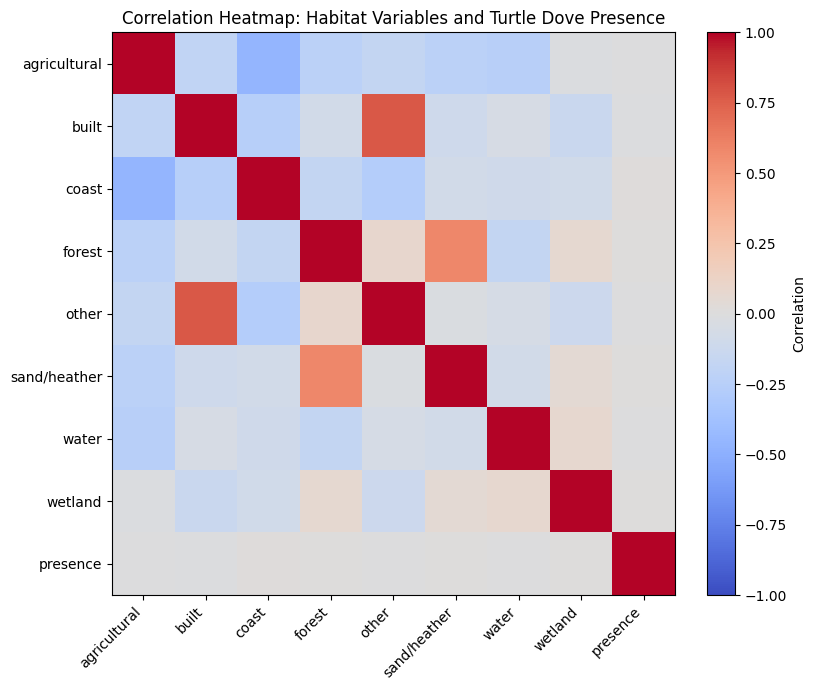

In [7]:
# Correlation Heatmap: Habitat Variables and Turtle Dove Presence

# Define the environmental columns to analyze
env_cols = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']

# Compute the correlation matrix including the 'presence' target variable
corr_matrix = merged_df[env_cols + ['presence']].corr(numeric_only=True)

# Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap: Habitat Variables and Turtle Dove Presence')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
plt.tight_layout()
plt.show()

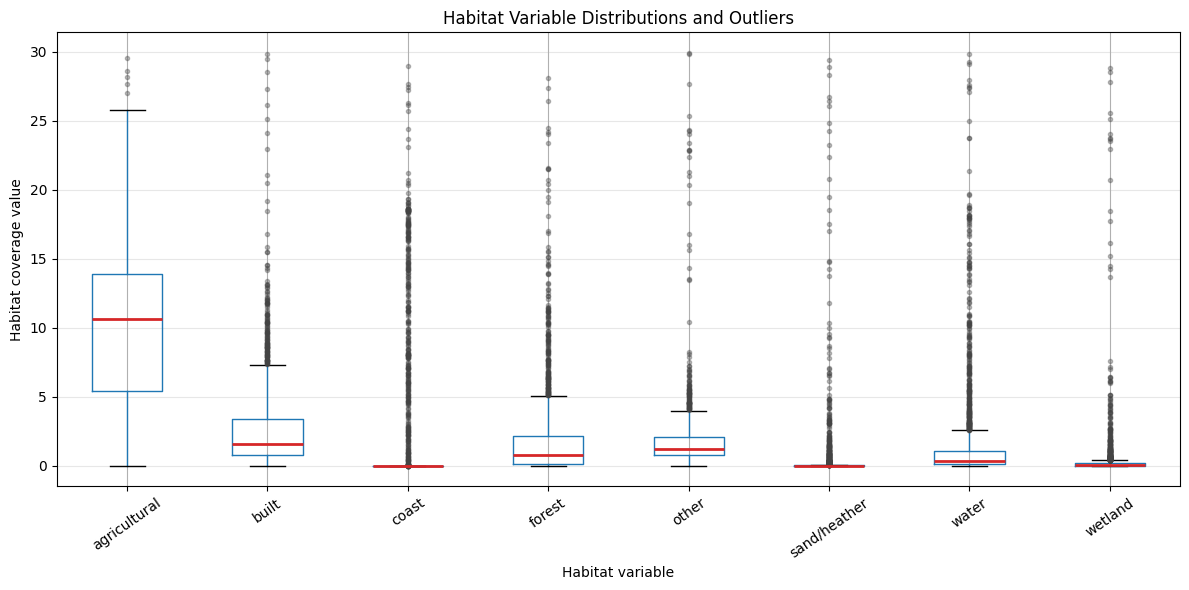

IQR outlier summary for habitat variables
    variable    q1  median     q3  lower_bound  upper_bound  outlier_count  outlier_percent
sand/heather 0.000   0.000  0.027       -0.040        0.068            424            19.46
       coast 0.000   0.000  0.000        0.000        0.000            366            16.80
     wetland 0.000   0.019  0.158       -0.237        0.395            311            14.27
       water 0.103   0.318  1.096       -1.387        2.586            286            13.13
      forest 0.153   0.735  2.124       -2.803        5.080            192             8.81
       built 0.780   1.584  3.391       -3.137        7.308            143             6.56
       other 0.735   1.213  2.042       -1.225        4.003            111             5.09
agricultural 5.394  10.624 13.883       -7.339       26.616              5             0.23


In [8]:
# Boxplots and IQR Outlier Summary for Habitat Variables

# Define the environmental columns to analyze
env_cols = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']

# Plot the boxplots to visualize distribution and outliers
fig, ax = plt.subplots(figsize=(12, 6))
habitats_df[env_cols].boxplot(
    ax=ax,
    showfliers=True,
    medianprops={'color': '#d62728', 'linewidth': 2},
    flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': '#444444', 'markeredgecolor': '#444444', 'alpha': 0.35}
)
ax.set_title('Habitat Variable Distributions and Outliers')
ax.set_xlabel('Habitat variable')
ax.set_ylabel('Habitat coverage value')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate IQR statistics and count outliers for each variable
outlier_rows = []
for col in env_cols:
    values = habitats_df[col]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()
    outlier_rows.append({
        'variable': col,
        'q1': round(q1, 3),
        'median': round(values.median(), 3),
        'q3': round(q3, 3),
        'lower_bound': round(lower_bound, 3),
        'upper_bound': round(upper_bound, 3),
        'outlier_count': int(outlier_count),
        'outlier_percent': round(outlier_count / len(values) * 100, 2)
    })

# Create and display the summary DataFrame
outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_count', ascending=False)
print('IQR outlier summary for habitat variables')
print(outlier_summary.to_string(index=False))

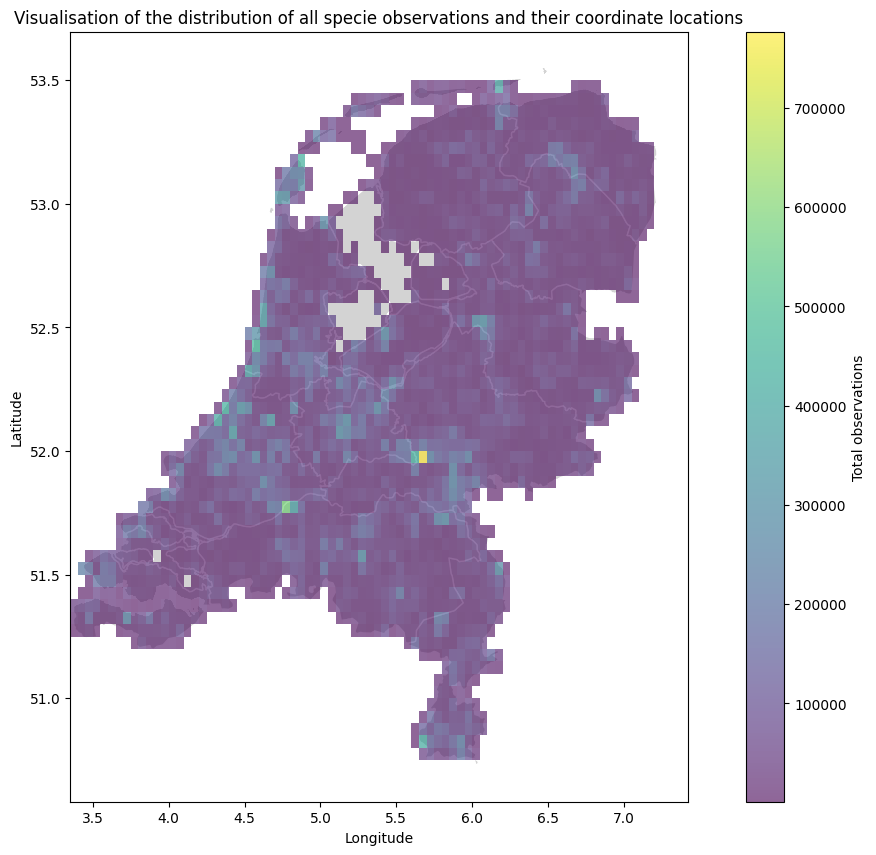

In [9]:
nl_layer = gpd.read_file("data/gadm41_NLD.gpkg", layer="ADM_ADM_1")
def show_distribution_map(df_map, nl):
    fig, ax = plt.subplots(figsize=(15, 10))
    nl.plot(ax=ax, color='lightgray', edgecolor='white')

    bin_w = 0.05
    x_bins = np.arange(df_map['decimalLongitude'].min(), df_map['decimalLongitude'].max() + bin_w, bin_w)
    y_bins = np.arange(df_map['decimalLatitude'].min(), df_map['decimalLatitude'].max() + bin_w, bin_w)

    heatmap, xedges, yedges = np.histogram2d(
        df_map['decimalLongitude'],
        df_map['decimalLatitude'],
        bins=[x_bins, y_bins],
        weights=df_map['total_observations']
    )

    heatmap = np.where(heatmap == 0, np.nan, heatmap)
    mesh = ax.pcolormesh(
        xedges,
        yedges,
        heatmap.T,
        alpha=0.6,
        cmap='viridis'
    )
    fig.colorbar(mesh, ax=ax, label='Total observations')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Visualisation of the distribution of all specie observations and their coordinate locations")
    plt.show()

show_distribution_map(merged_df, nl_layer)

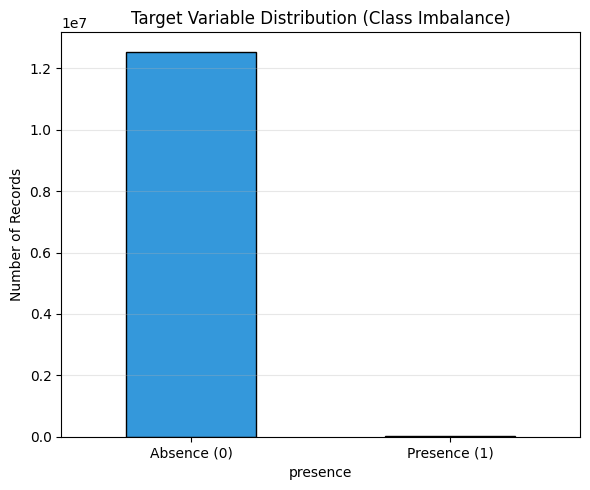

In [10]:

# Bar Chart: Count of Absence (0) vs Presence (1)

# Get the counts of each class
class_counts = merged_df['presence'].value_counts()

# Plot the class distribution
fig, ax = plt.subplots(figsize=(6, 5))
class_counts.plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='black', ax=ax)

ax.set_title('Target Variable Distribution (Class Imbalance)')
ax.set_xticklabels(['Absence (0)', 'Presence (1)'], rotation=0)
ax.set_ylabel('Number of Records')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

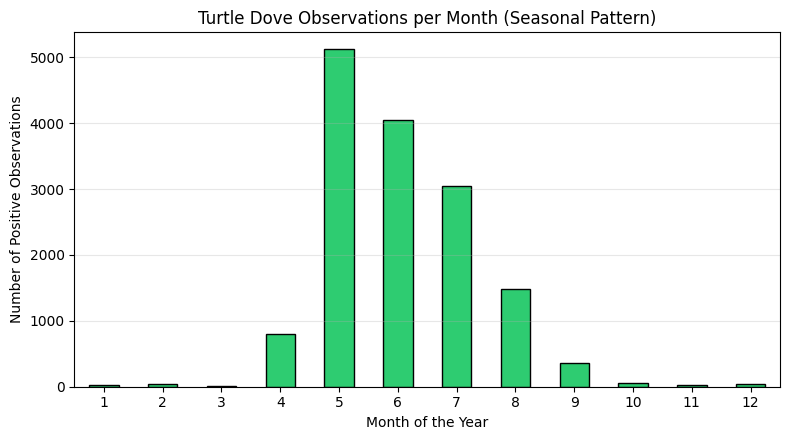

In [11]:
# Bar Chart: Number of Bird Presences Per Month

# Filter dataset to only include rows where the bird was actually seen (presence == 1)
presence_only_df = merged_df[merged_df['presence'] == 1]

# Check if 'month' column exists before plotting
if 'month' in merged_df.columns:
    # Count observations per month and sort chronologically
    monthly_observations = presence_only_df['month'].value_counts().sort_index()
    
    # Plot seasonal distribution
    fig, ax = plt.subplots(figsize=(8, 4.5))
    monthly_observations.plot(kind='bar', color='#2ecc71', edgecolor='black', ax=ax)
    
    ax.set_title('Turtle Dove Observations per Month (Seasonal Pattern)')
    ax.set_xlabel('Month of the Year')
    ax.set_ylabel('Number of Positive Observations')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("Warning: 'month' not found.")

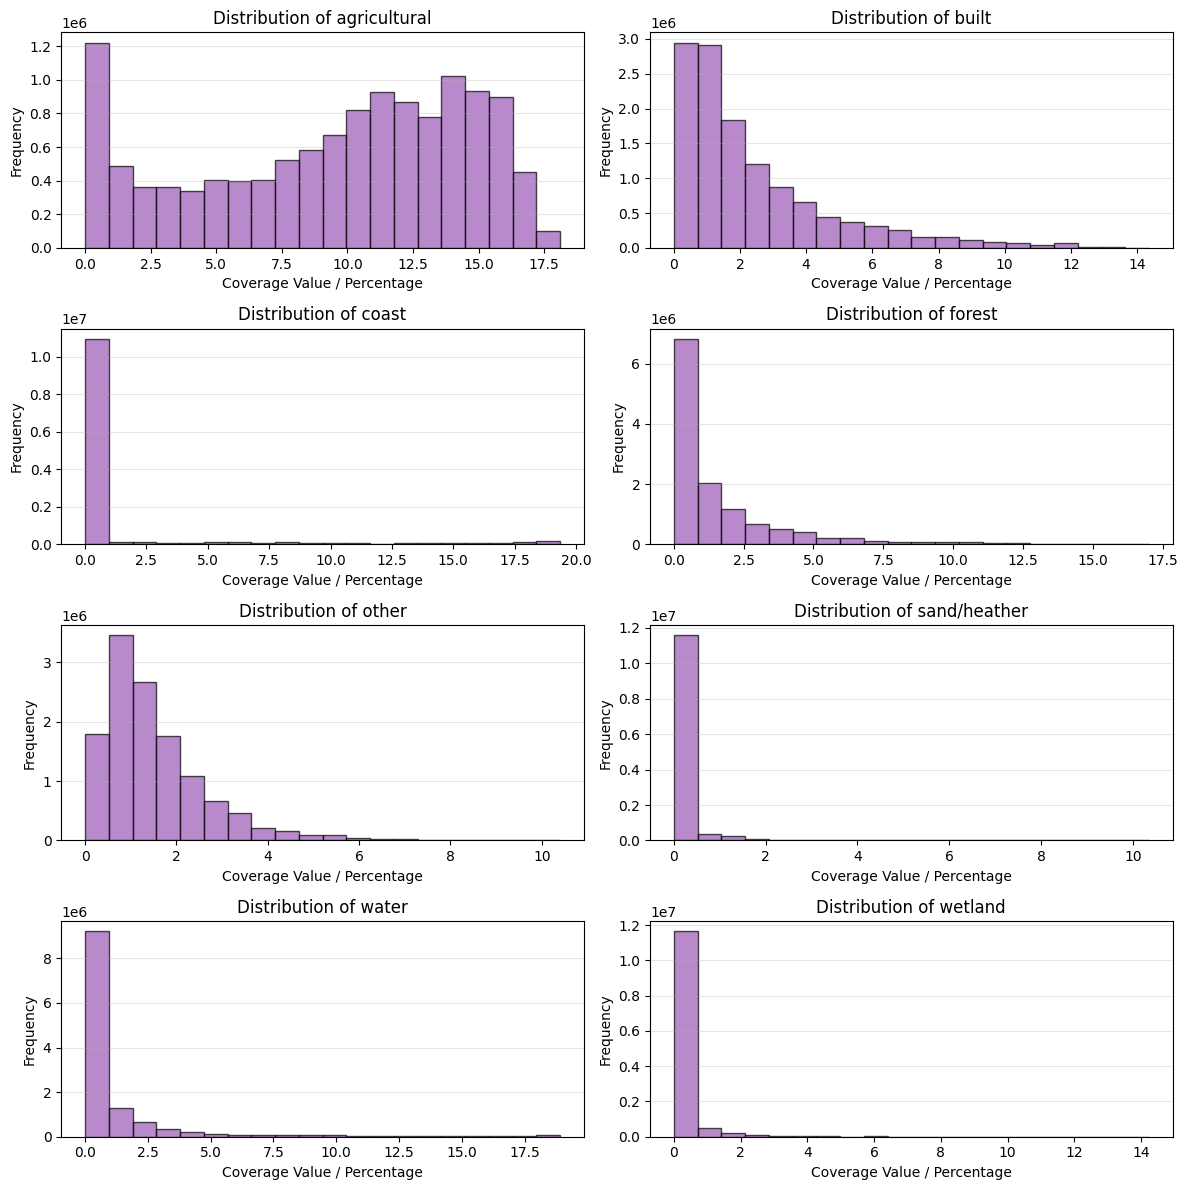

In [12]:
# Histograms: Distribution shapes for all habitat variables

# Set up a grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

# Plot a histogram for each habitat variable
for i, col in enumerate(env_cols):
    axes[i].hist(merged_df[col], bins=20, color='#9b59b6', alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Coverage Value / Percentage')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

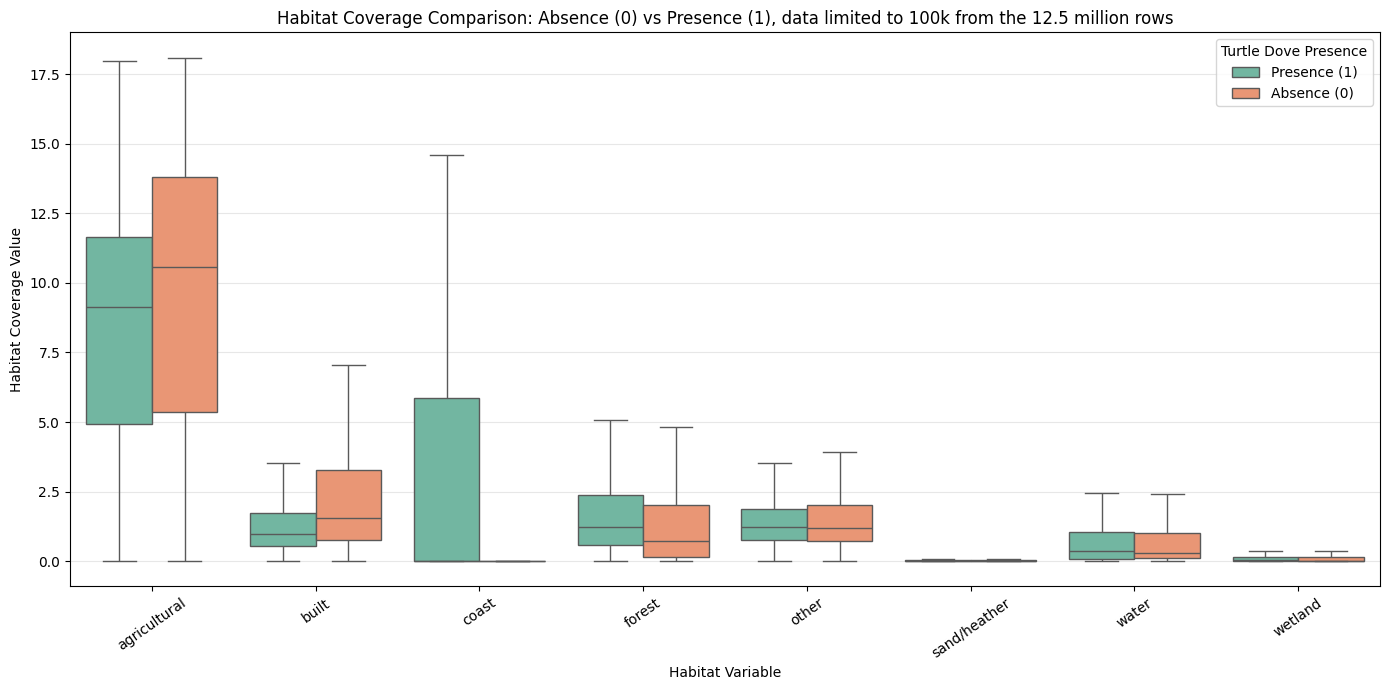

In [13]:
# Grouped Boxplots: Comparing habitat coverage when bird is Absent vs Present

# Get ONLY the row numbers (indices) where presence is 0
absence_indices = merged_df.index[merged_df['presence'] == 0]

# Randomly sample 100,000 row numbers from that list
np.random.seed(42) 
sample_size = min(100000, len(absence_indices))
sampled_indices = np.random.choice(absence_indices, size=sample_size, replace=False)

# Pull ONLY those 100,000 rows, and combine them with the rare presence rows (1)
absence_sample = merged_df.loc[sampled_indices]
presence_df = merged_df[merged_df['presence'] == 1]

plot_sample_df = pd.concat([presence_df, absence_sample])

# Melt the tiny sampled dataframe
melted_habitats = pd.melt(
    plot_sample_df, 
    id_vars=['presence'], 
    value_vars=env_cols, 
    var_name='habitat_type', 
    value_name='coverage_value'
)

melted_habitats['presence'] = melted_habitats['presence'].map({
    0: 'Absence (0)', 
    1: 'Presence (1)'
})

# Plot grouped boxplots using Seaborn
plt.figure(figsize=(14, 7))
sns.boxplot(
    x='habitat_type', 
    y='coverage_value', 
    hue='presence', 
    data=melted_habitats, 
    palette='Set2', 
    showfliers=False
)

plt.title('Habitat Coverage Comparison: Absence (0) vs Presence (1), data limited to 100k from the 12.5 million rows')
plt.xlabel('Habitat Variable')
plt.ylabel('Habitat Coverage Value')
plt.xticks(rotation=35)
plt.grid(axis='y', alpha=0.3)

plt.legend(title='Turtle Dove Presence')

plt.tight_layout()
plt.show()

## Benchmark model

In [14]:
# Benchmark Model

# Note: turtur_df, habitats_df, and merged_df are already loaded and processed.
# We reuse them here to display previews and calculate the baseline performance.

# Preview datasets
print("Turtle dove data preview:")
print(turtur_df.head())

print("\nHabitat data preview:")
print(habitats_df.head())

# Check class distribution
print("\nClass Distribution:")
print(merged_df['presence'].value_counts())

# Find majority class
majority_class = merged_df['presence'].mode()[0]

print(f"\nMajority Class: {majority_class}")

# Calculate benchmark accuracy
benchmark_accuracy = (
    merged_df['presence'] == majority_class
).mean()

print(f"\nBenchmark Accuracy: {benchmark_accuracy:.2%}")

Turtle dove data preview:
   decimalLatitude  decimalLongitude  total_observations  \
0            50.75              5.65                 0.0   
1            50.75              5.65                26.0   
2            50.75              5.65                 3.0   
3            50.75              5.65                 0.0   
4            50.75              5.65                 0.0   

   speciesgroup_observations  Streptopelia_turtur  presence  year  month  day  \
0                          0                  0.0         0  2010      1    1   
1                         26                  0.0         0  2010      1    2   
2                          3                  0.0         0  2010      1    3   
3                          0                  0.0         0  2010      1    4   
4                          0                  0.0         0  2010      1    5   

   day_of_week  
0            4  
1            5  
2            6  
3            0  
4            1  

Habitat data preview:
 

## Data preperation

In [15]:
# Define X and y from the merged dataset
X = merged_df.drop(columns=['Streptopelia_turtur', 'presence'])
y = merged_df['presence']

# Convert categorical text columns (like 'main_habitat') into numerical dummy columns (One-Hot Encoding)
# This transforms 'coast', 'forest' etc. into separate columns with 1s and 0s so the model can read them
X = pd.get_dummies(X, columns=['main_habitat'], dtype=int)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Resample the training data
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# Save the downsampled training data to CSV (including the new habitat columns)
train_resampled_df = pd.DataFrame(X_train_resampled, columns=X.columns)
train_resampled_df['presence'] = y_train_resampled
train_resampled_df.to_csv('data/downSampBirdData_train.csv', index=False)

print(f"The downsampel trainingsset has {len(train_resampled_df)} rows.")

The downsampel trainingsset has 24074 rows.


## Modeling

In [16]:
# Baseline RF model without any hyperparameter tuning or whatsoever

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9580527854660811
[[2403581  105162]
 [    199    2810]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   2508743
           1       0.03      0.93      0.05      3009

    accuracy                           0.96   2511752
   macro avg       0.51      0.95      0.51   2511752
weighted avg       1.00      0.96      0.98   2511752



In [18]:
# ==============================================================================
# FINAL TUNED RANDOM FOREST MODEL WITH 5-FOLD CROSS-VALIDATION
# ==============================================================================

# 1. Prepare Features (X) and Target (y)
# CRITICAL: Drop coordinates and raw counts to force the model to learn habitat relationships!
feature_cols = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland', 'month']
X = merged_df[feature_cols]
y = merged_df['presence']

# 2. Define the Imbalanced-Learn Pipeline
# This guarantees that downsampling happens STRICTLY within the training folds of the CV
pipeline = ImbPipeline([
    ('undersampler', RandomUnderSampler(sampling_strategy='auto', random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1)) # n_jobs=-1 uses all CPU cores
])

# 3. Define the Hyperparameter Grid for Tuning
# We focus on parameters that control overfitting and handle class imbalance
param_distributions = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 15, 20, 25, None],
    'classifier__min_samples_leaf': [5, 10, 20, 50],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None]
}

# 4. Set up Stratified 5-Fold Cross-Validation
# Stratified ensures each fold maintains the 99.88% vs 0.12% balance during testing
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Initialize RandomizedSearchCV
# We use 'f1_macro' or a custom scorer to optimize for the minority class, not standard accuracy!
rf_tuned_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,               # Number of random combinations to try (saves hours of computation)
    scoring='f1_macro',      # Guides the search to find models that score well on both classes
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=2                # Prints progress updates during training
)

# 6. Run the Tuning Pipeline (This may take a few minutes due to data size)
print("Starting Hyperparameter Tuning with 5-Fold Cross-Validation...")
rf_tuned_search.fit(X, y)

# 7. Extract the Best Model and Parameters
best_pipeline = rf_tuned_search.best_estimator_
print("\n=== Best Hyperparameters Found ===")
print(rf_tuned_search.best_params_)

Starting Hyperparameter Tuning with 5-Fold Cross-Validation...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


MemoryError: Unable to allocate 76.7 MiB for an array with shape (10047005, 1) and data type float64

In [ ]:
# ==============================================================================
# EVALUATION: CALCULATING F1-SCORE PER K-FOLD WITH CUSTOM THRESHOLD
# ==============================================================================

# 1. We pakken de beste instellingen die de RandomizedSearch net heeft gevonden
best_params = rf_tuned_search.best_params_

# Schoon de parameter-namen op (verwijder 'classifier__' voorvoegsel voor direct gebruik)
clean_params = {k.replace('classifier__', ''): v for k, v in best_params.items()}

# 2. Stel de gewenste strenge grens (threshold) in om False Positives te tackelen
custom_threshold = 0.85

# Lijst om de F1-scores van elke fold in op te slaan
fold_f1_scores = []

print(f"=== F1-Scores per K-Fold (Minority Class 'Presence') met Threshold {custom_threshold} ===")
print("-" * 70)

# 3. Loop handmatig door de 5 folds heen
# StratifiedKFold zorgt ervoor dat elke fold 99.88% vs 0.12% data bevat
for fold, (train_idx, test_idx) in enumerate(cv_strategy.split(X, y), 1):
    
    # Splits de data op in de huidige trainings-folds en de onbekende test-fold
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    
    # Bouw een verse pipeline op met de optimale instellingen
    fold_pipeline = ImbPipeline([
        ('undersampler', RandomUnderSampler(sampling_strategy='auto', random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
    ])
    fold_pipeline.named_steps['classifier'].set_params(**clean_params)
    
    # Train het model op de trainingsdata van DEZE fold (hier wordt ook gedownsampled)
    fold_pipeline.fit(X_train_fold, y_train_fold)
    
    # Voorspel de KANSEN op de test-fold (die het model nog NOOIT heeft gezien)
    y_prob_fold = fold_pipeline.predict_proba(X_test_fold)[:, 1]
    
    # Pas de strenge custom threshold toe (alles boven 85% wordt pas een vogel-aanwezigheid)
    y_pred_fold = (y_prob_fold >= custom_threshold).astype(int)
    
    # Bereken de F1-score STRIKT op de zeldzame klasse (1 = Presence) conform jullie SMART-doel!
    score = f1_score(y_test_fold, y_pred_fold, pos_label=1)
    fold_f1_scores.append(score)
    
    print(f"Fold {fold}: F1-score voor Presence (1) = {score:.4f}")

# 4. Bereken het uiteindelijke gemiddelde
print("-" * 70)
print(f"Gemiddelde F1-score over alle 5 de folds: {np.mean(fold_f1_scores):.4f}")